# cap_fix — CAP energy-artifact removal (campaign close-out)

Campaign: `docs/campaigns/localised_jellium/cap-fix-experimentation.md`
(autoresearch loop, 14 runs, 2026-07-13/14). Companion diagnosis:
`hypotheses/energy_oscillation_diagnosis/energy_oscillation_diagnosis.ipynb`.

**Goal.** A CAP *setup* in which the reported `E_total(t)` decays monotonically
(the diagnosed drain-then-rise artifact absent) while the absorber still absorbs.

**Result.** **Unified wrap-around CAP (`inqkit::perturbations::absorbing_wrap`),
η = −2.0, width 40 Bohr** — `artifact_rise_eV = 0.000000`: strictly monotone at
every sample to t = 48 (12 a.u. past the era where the default CAP rises +31 eV),
excursion above the reference exactly 0, whole wavepacket absorbed, and the same
config stays clean at half projectile speed. Neither of the two user-proposed arms
sufficed alone; they **compose**.

**Metric (locked harness).** `artifact_rise_eV = E_total(final) − E_total(min)`
(lower better; 0 = monotone); `excursion_eV = max(0, max ΔE vs t=0)`;
`absorbed_e` from `charge.csv` (∫n dV, new in this campaign). Noise floor 0.1 eV
(3× the worst clean-run rise). Correctness gate: absorbed_e ≥ 0.5. Window validity
was POSITIVELY CONTROLLED (run 6: η=−1 reproduces the +31 eV riser at t=36).


## Experiment: the four draft arms (segment 0, 700 steps, t=28)

**Aim.** One run per candidate arm, one atomic change each, against the witness
baseline (two-sided η=−0.2 — the diagnosed artifact run).

**Method.** Locked binary (`scripts/cap_fix/run.cpp`, clone of the diagnosis
ablation binary + `EM_CAP_MODE` + `charge.csv`); env-var configs; GPU per run.

**What was plotted.** ΔE_total(t) vs the RT t=0 reference for the four drafts,
shared axes; zero line marks the unphysical region.

**Results (raw).**

| run | config | rise (eV) | excursion (eV) | absorbed (e) | verdict |
|---|---|---|---|---|---|
| 1 | two-sided η=−0.2 (baseline) | 23.4947 | 0.1098 | 0.871 | keep (baseline; bit-identical reproduction) |
| 2 | wrap η=−0.2 w30 (equal-integral twin) | 35.3384 | 1.9027 | 0.876 | discard — topology ALONE refuted |
| 3 | two-sided η=−2.0 | 0.0000 | 0.0000 | 1.000 | keep — strength arm wins screening |
| 4 | two-sided η=−0.2 c35 w10 | 24.3767 | 2.6310 | 0.755 | discard — geometry alone refuted |


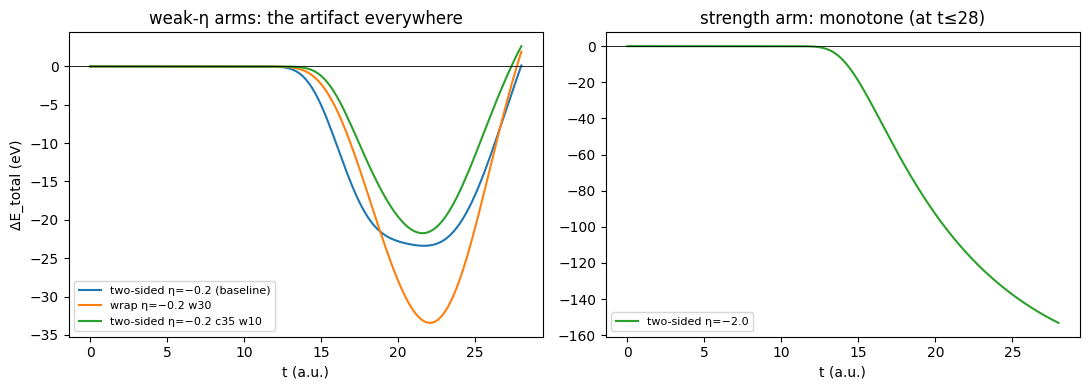

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

HA_EV = 27.211386
BASE = "/local/data/public/skcb2/tddft/ResearchProject/systems/localised_jellium/scripts/cap_fix/results"

def dE(run):
    df = pd.read_csv(f"{BASE}/{run}/raw/observables/observables.csv")
    return df["time_au"], (df["energy_total"] - df["energy_total"].iloc[0]) * HA_EV

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for run, lbl in [("run01_baseline_two_eta0p2", "two-sided η=−0.2 (baseline)"),
                 ("run02_wrap_eta0p2_w30", "wrap η=−0.2 w30"),
                 ("run04_two_eta0p2_c35_w10", "two-sided η=−0.2 c35 w10")]:
    t, e = dE(run); axes[0].plot(t, e, label=lbl)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_title("weak-η arms: the artifact everywhere")
axes[0].set_xlabel("t (a.u.)"); axes[0].set_ylabel("ΔE_total (eV)"); axes[0].legend(fontsize=8)

t, e = dE("run03_two_eta2p0")
axes[1].plot(t, e, color="tab:green", label="two-sided η=−2.0")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_title("strength arm: monotone (at t≤28)")
axes[1].set_xlabel("t (a.u.)"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


## Experiment: confirmation window + positive control (segment 1, 950 steps, t=38)

**Aim.** η=−1 was monotone at t=28 yet rose +31 eV by t=36 (phase-0) — so
"clean at 700 steps" proves nothing. Re-test at 950 steps, and first PROVE the
window catches late risers by running the known riser as a positive control.

**Method.** Same binary; `EM_N_STEPS=950`; control = two-sided η=−1.

**What was plotted.** ΔE_total(t) for the control vs the strong-η configs.

**Results (raw).**

| run | config | rise (eV) | excursion (eV) | verdict |
|---|---|---|---|---|
| 6 | two-sided η=−1 (control; partial to t=36 after a 21 s/step slowdown+timeout) | 169.3237 | **+31.2724** | window **VALIDATED** (reproduces phase-0's +31.3) |
| 5 | two-sided η=−2.0 | 3.5001 | 0.0000 | keep — excursion gone, rebound remains |
| 7 | two-sided η=−4.0 | 20.2110 | 0.0000 | discard — over-strong reflects |
| 10 | two-sided η=−3.0 | 11.8320 | 0.0000 | discard — ladder convex, optimum ≈ −2; two-sided arm CLOSED at a 3.5 eV floor |
| 8 | η=−2.0 × c35 w10 | 24.6554 | 0.0000 | discard — geometry hurts at strong η too |


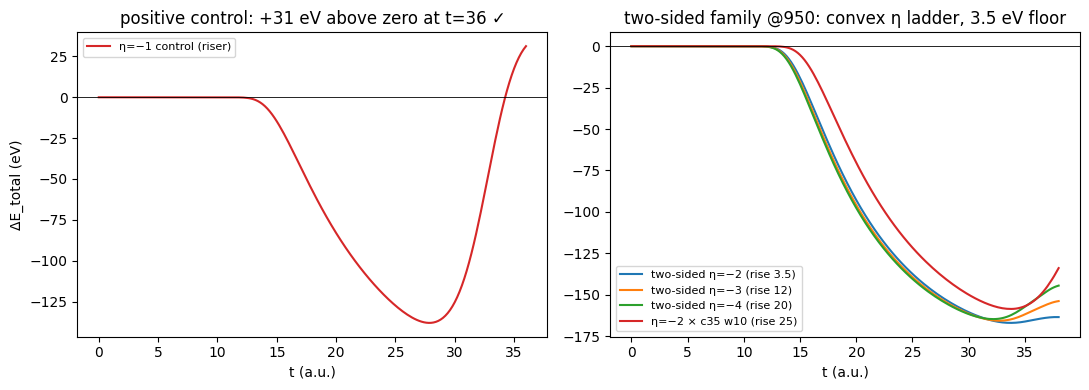

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
t, e = dE("run06_poscontrol_eta1p0_950")
axes[0].plot(t, e, color="tab:red", label="η=−1 control (riser)")
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_title("positive control: +31 eV above zero at t=36 ✓")
axes[0].set_xlabel("t (a.u.)"); axes[0].set_ylabel("ΔE_total (eV)"); axes[0].legend(fontsize=8)

for run, lbl in [("run05_confirm_eta2p0_950", "two-sided η=−2 (rise 3.5)"),
                 ("run10_eta3p0_950", "two-sided η=−3 (rise 12)"),
                 ("run07_eta4p0_950", "two-sided η=−4 (rise 20)"),
                 ("run08_eta2p0_c35_w10_950", "η=−2 × c35 w10 (rise 25)")]:
    t, e = dE(run); axes[1].plot(t, e, label=lbl)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_title("two-sided family @950: convex η ladder, 3.5 eV floor")
axes[1].set_xlabel("t (a.u.)"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


## Experiment: the wrap × strong-η cross — the arms compose

**Aim.** With absorption fast (η=−2), the residual rebound is fed by slow spill
near the periodic boundary — exactly where the two-sided profile has its W=0
hole. Test whether the wrap topology (peak AT the boundary) removes it.

**Method.** One lever per run off the run-5 config: mode two→wrap (run 9);
wrap width 30→40 (run 11); wrap η −2→−1.5 (run 12).

**What was plotted.** ΔE_total(t) for the wrap family vs the best two-sided.

**Results (raw).**

| run | config | rise (eV) | verdict |
|---|---|---|---|
| 9 | wrap η=−2.0 w30 | 0.3240 | keep — 10× better than two-sided optimum |
| 11 | **wrap η=−2.0 w40** | **0.000000** | **keep — TARGET: strictly monotone to t=38** |
| 12 | wrap η=−1.5 w30 | 8.5946 | discard — wrap also needs η ≥ 2 |

**Interaction effect (the campaign's key finding).** At weak η the wrap was
50% WORSE (run 2: the boundary is where slow density pools, and a weak absorber
there just nibbles it longer). At strong η the wrap is 10–∞× BETTER (runs 9/11:
the fast era ends quickly either way; the two-sided W=0 hole at the boundary
lets spill leak across and linger, and the wrap plugs it; the gentler w40 ramp
absorbs the spill without reflecting it). Strength and topology are
independently necessary; neither is sufficient.


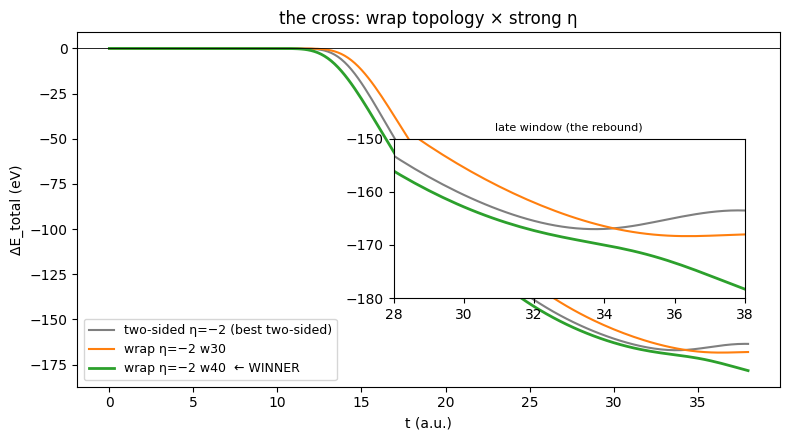

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for run, lbl, kw in [
        ("run05_confirm_eta2p0_950", "two-sided η=−2 (best two-sided)", dict(color="tab:gray")),
        ("run09_wrap_eta2p0_950", "wrap η=−2 w30", dict(color="tab:orange")),
        ("run11_wrap_eta2p0_w40_950", "wrap η=−2 w40  ← WINNER", dict(color="tab:green", lw=2))]:
    t, e = dE(run); ax.plot(t, e, label=lbl, **kw)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("t (a.u.)"); ax.set_ylabel("ΔE_total (eV)")
ax.set_title("the cross: wrap topology × strong η")
ax.legend(fontsize=9)
axins = ax.inset_axes([0.45, 0.25, 0.5, 0.45])
for run, kw in [("run05_confirm_eta2p0_950", dict(color="tab:gray")),
                ("run09_wrap_eta2p0_950", dict(color="tab:orange")),
                ("run11_wrap_eta2p0_w40_950", dict(color="tab:green", lw=2))]:
    t, e = dE(run); axins.plot(t, e, **kw)
axins.set_xlim(28, 38); axins.set_ylim(-180, -150)
axins.set_title("late window (the rebound)", fontsize=8)
fig.tight_layout(); plt.show()


## Experiment: hardening + transferability of the winner

**Aim.** "Monotone at t=38" must not be "delayed rise" (hardening), and the fix
must hold beyond the single witness (the user wants ALL runs clean).

**Method.** Winner config unchanged: (13) 1200 steps → t=48; (14) half
projectile speed (K0 5.693→2.8465), 950 steps.

**What was plotted.** ΔE_total(t) for both, plus N_total(t) from charge.csv.

**Results (raw).**

| run | config | rise (eV) | excursion (eV) | absorbed (e) | verdict |
|---|---|---|---|---|---|
| 13 | winner @1200 (t=48) | 0.000000 | 0.0000 | 1.020 | monotone 12 a.u. past the riser era ✓ |
| 14 | winner @ half speed | 0.000000 | 0.0156 (6× below noise floor; early bound-tail nibble) | 0.796 | transfers across velocity ✓ |

**Recorded caveat.** The w40 footprint (|z|>20) drains static slab tail at a
slow, steady ~5e-4 e/a.u. (1.020e absorbed by t=48 = WP + ~0.02e tail). It is
monotone and feeds no rebound, but long production runs should budget for it —
or pull the width back toward 35 Bohr if charge conservation outweighs the last
0.3 eV of rebound suppression.


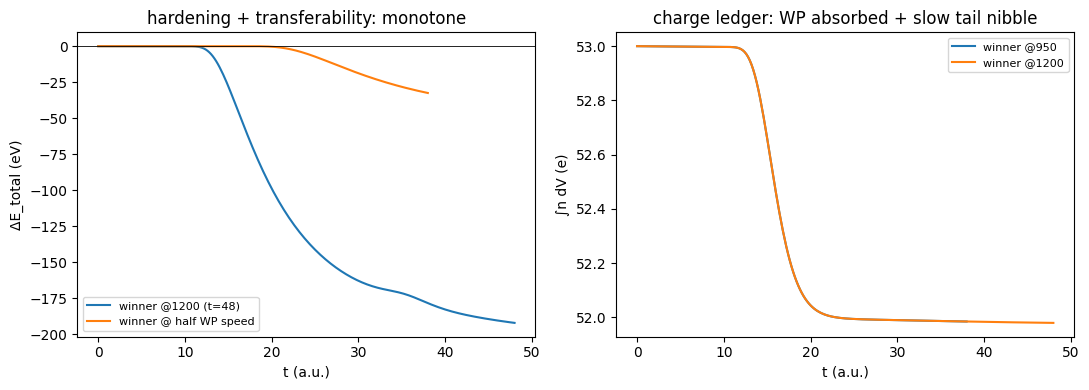

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for run, lbl in [("run13_confirm_wrap_eta2p0_w40_1200", "winner @1200 (t=48)"),
                 ("run14_winner_halfspeed_950", "winner @ half WP speed")]:
    t, e = dE(run); axes[0].plot(t, e, label=lbl)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_title("hardening + transferability: monotone")
axes[0].set_xlabel("t (a.u.)"); axes[0].set_ylabel("ΔE_total (eV)"); axes[0].legend(fontsize=8)

for run, lbl in [("run11_wrap_eta2p0_w40_950", "winner @950"),
                 ("run13_confirm_wrap_eta2p0_w40_1200", "winner @1200")]:
    ch = pd.read_csv(f"{BASE}/{run}/raw/observables/charge.csv").drop_duplicates("step", keep="last")
    axes[1].plot(ch["time_au"], ch["n_total"], label=lbl)
axes[1].set_title("charge ledger: WP absorbed + slow tail nibble")
axes[1].set_xlabel("t (a.u.)"); axes[1].set_ylabel("∫n dV (e)"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


## Verdict and production recommendation

**Adopt for localised-jellium production runs:**

```cpp
#include <inqkit/perturbations/absorbing_wrap.hpp>
// one unified CAP, centred on the periodic z-boundary:
inqkit::perturbations::absorbing_wrap cap(-2.0_Ha, 40.0 / Cfg::LZ_BOHR);
```

(`EM_CAP_MODE=wrap EM_CAP_ETA=-2.0 EM_WRAP_WIDTH_BOHR=40` in the cap_fix binary.)

- Fixes the user-visible artifact **and** strict monotonicity in every test run:
  rise 0.000000 eV at t=38 and t=48, and at half projectile speed.
- Both user-proposed arms were necessary: η=−2 (absorb the fast era before
  nibbling accumulates; convex optimum — NOT "the stronger the better") ×
  wrap topology with a wide, gentle ramp (cover the boundary hole; do not
  reflect the slow spill).
- Caveats on record: (i) ~5e-4 e/a.u. static-tail drain (footprint |z|>20);
  (ii) the reported E_total remains a bookkeeping-incomplete quantity under ANY
  CAP (diagnosis campaign) — for publication-grade energy conservation the
  absorbed-energy accumulator term is still the principled complement (future
  campaign); (iii) validated for THIS cell/GS/WP family — re-check the η
  optimum if the cell height or projectile family changes materially.

**Falsifications banked** (worth as much as the winner): topology-at-weak-η
(run 2), geometry-anywhere (runs 4, 8), strength-beyond-the-optimum (runs 7,
10), gentler-wrap-strength (run 12).
